In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
df = pd.read_csv(r"C:\Users\PC\Downloads\diabetes.csv")

In [64]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [65]:
df.shape

(768, 9)

In [66]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [67]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [68]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [70]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [71]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [72]:
df[cols].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578
std,31.972618,19.355807,15.952218,115.244002,7.884160
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000
50%,117.000000,72.000000,23.000000,30.500000,32.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


In [73]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [74]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


C:\Users\PC\AppData\Local\Temp\ipykernel_34280\2421988225.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viss1=df.groupby('AgeGroup')['Outcome'].sum()


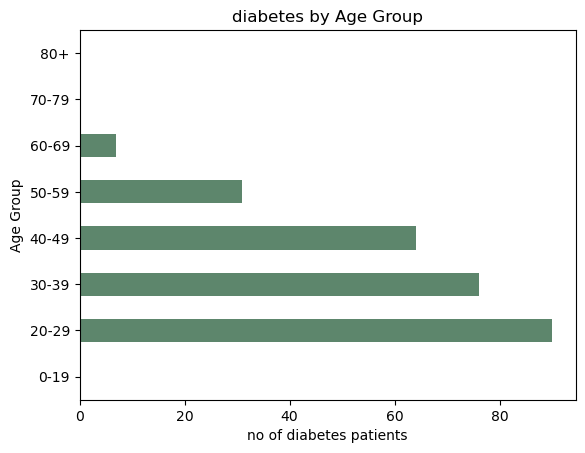

In [75]:
bins1 = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels1 = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins1, labels=labels1)

viss1=df.groupby('AgeGroup')['Outcome'].sum()

viss1.plot(kind='barh', color='#5D866C')

plt.xlabel('no of diabetes patients')
plt.ylabel('Age Group')
plt.title('diabetes by Age Group')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_34280\2975046706.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viss2 = df.groupby(pd.cut(df['Pregnancies'], bins=bins2, labels=labels2))['Outcome'].mean() * 100


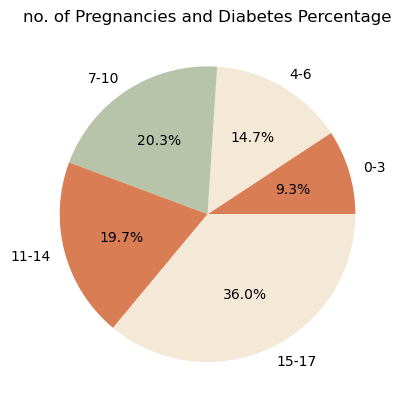

In [76]:
##pregnant with diabetes percentage
bins2 = [0, 4, 7, 11, 15, 17]
labels2 = ['0-3','4-6','7-10','11-14','15-17']

viss2 = df.groupby(pd.cut(df['Pregnancies'], bins=bins2, labels=labels2))['Outcome'].mean() * 100


colors=['#D97D55','#F4E9D7','#B8C4A9']
plt.pie(viss2.values, labels=viss2.index, colors=colors, autopct='%1.1f%%')
plt.title('no. of Pregnancies and Diabetes Percentage')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_34280\2139268660.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viss3=df[df['Insulin'] > 0].groupby(pd.cut(df['Insulin'], bins=bins3, labels=labels3))['Outcome'].sum()


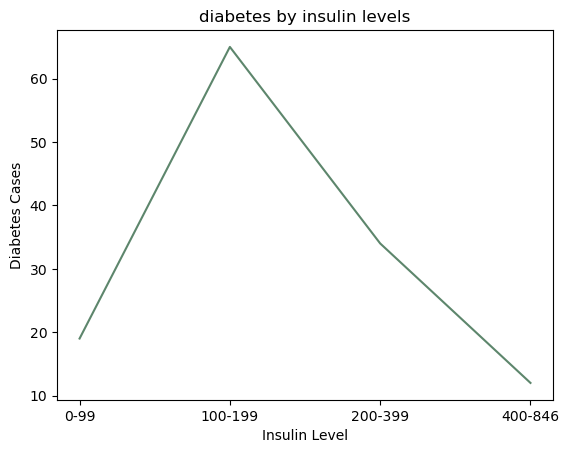

In [77]:
bins3 = [0, 100, 200, 400, 900]   
labels3 = ['0-99', '100-199', '200-399', '400-846']

viss3=df[df['Insulin'] > 0].groupby(pd.cut(df['Insulin'], bins=bins3, labels=labels3))['Outcome'].sum()

sns.lineplot(x=viss3.index, y=viss3.values,color='#5D866C')
plt.title('diabetes by insulin levels')
plt.xlabel('Insulin Level')
plt.ylabel('Diabetes Cases')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_34280\3869104722.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viss4=df[df['BMI'] > 0].groupby(pd.cut(df['BMI'], bins=bins4, labels=labels4))['Outcome'].sum()


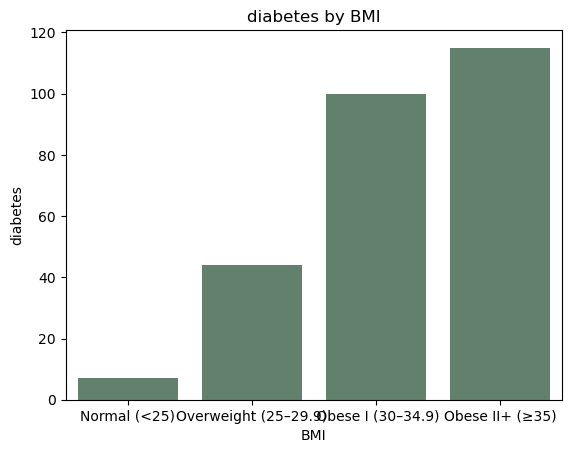

In [78]:
## bmi and diabetese
bins4 = [0, 25, 30, 35, df['BMI'].max()]
labels4 = ['Normal (<25)', 'Overweight (25–29.9)', ' Obese I (30–34.9)', 'Obese II+ (≥35)']
viss4=df[df['BMI'] > 0].groupby(pd.cut(df['BMI'], bins=bins4, labels=labels4))['Outcome'].sum()

sns.barplot(x=viss4.index, y=viss4.values,color='#5D866C')

plt.title('diabetes by BMI')
plt.xlabel('BMI')
plt.ylabel('diabetes')
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_34280\3034226470.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viss1 = df.groupby('AgeGroup')['Outcome'].sum()
C:\Users\PC\AppData\Local\Temp\ipykernel_34280\3034226470.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viss2 = df.groupby(pd.cut(df['Pregnancies'], bins=bins2, labels=labels2))['Outcome'].mean() * 100
C:\Users\PC\AppData\Local\Temp\ipykernel_34280\3034226470.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to

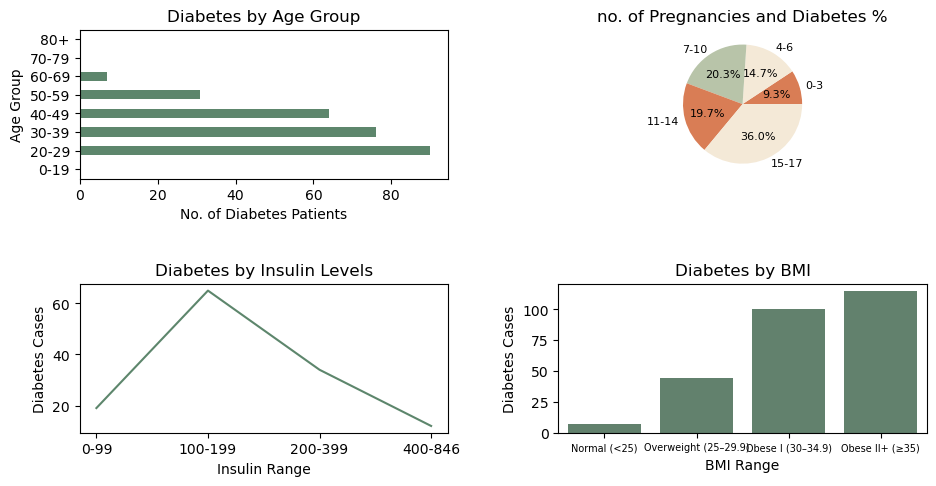

In [79]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,5.5))
ax1, ax2, ax3, ax4 = axes.flatten()


viss1 = df.groupby('AgeGroup')['Outcome'].sum()
viss1.plot(kind='barh', color='#5D866C', ax=ax1)
ax1.set_xlabel('No. of Diabetes Patients')
ax1.set_ylabel('Age Group')
ax1.set_title('Diabetes by Age Group')


bins2 = [0, 4, 7, 11, 15, 17]
labels2 = ['0-3','4-6','7-10','11-14','15-17']
viss2 = df.groupby(pd.cut(df['Pregnancies'], bins=bins2, labels=labels2))['Outcome'].mean() * 100
colors=['#D97D55','#F4E9D7','#B8C4A9']
ax2.pie(viss2.values, labels=viss2.index, colors=colors, autopct='%1.1f%%',textprops={'fontsize':8})
ax2.set_title('no. of Pregnancies and Diabetes %')


bins3 = [0, 100, 200, 400, 900]   
labels3 = ['0-99', '100-199', '200-399', '400-846']
viss3 = df[df['Insulin'] > 0].groupby(pd.cut(df['Insulin'], bins=bins3, labels=labels3))['Outcome'].sum()
sns.lineplot(x=viss3.index, y=viss3.values, color='#5D866C', ax=ax3)
ax3.set_title('Diabetes by Insulin Levels')
ax3.set_xlabel('Insulin Range')
ax3.set_ylabel('Diabetes Cases')


bins4 = [0, 25, 30, 35, df['BMI'].max()]
labels4 = ['Normal (<25)', 'Overweight (25–29.9)', 'Obese I (30–34.9)', 'Obese II+ (≥35)']
viss4 = df[df['BMI'] > 0].groupby(pd.cut(df['BMI'], bins=bins4, labels=labels4))['Outcome'].sum()
sns.barplot(x=viss4.index, y=viss4.values, color='#5D866C', ax=ax4)
ax4.set_title('Diabetes by BMI')
ax4.set_xlabel('BMI Range',fontsize=10)
ax4.set_ylabel('Diabetes Cases')
ax4.tick_params(axis='x', labelsize=7)

plt.tight_layout(pad=3)

plt.show()


In [80]:
# separating the data and labels
X = df.drop(['Outcome', 'AgeGroup'], axis=1)
y = df['Outcome']

In [81]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [82]:
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [83]:
#train Test Split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, stratify=y, random_state=2)

In [85]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


In [86]:
#feature Scaling 

In [87]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
#logistic regression training  model 
classifier = LogisticRegression(max_iter=1000 )
classifier.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [89]:
# Model prediction ,evaluation 

In [129]:
 # accuracy score on the training data
X_train_prediction = classifier.predict(X_train_scaled)
training_data_accuracy = accuracy_score(X_train_prediction, y_train)

In [130]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.7850162866449512


In [131]:
# accuracy score on the test data
X_test_prediction = classifier.predict(X_test_scaled)
test_data_accuracy = accuracy_score(X_test_prediction, y_test)

In [132]:
print('Accuracy score of the test data : ', test_data_accuracy)


Accuracy score of the test data :  0.7597402597402597


In [134]:
y_prob =classifier.predict_proba(X_test_scaled)

print(y_prob[:5])

[[0.92493588 0.07506412]
 [0.91284739 0.08715261]
 [0.36951001 0.63048999]
 [0.33466602 0.66533398]
 [0.88312595 0.11687405]]


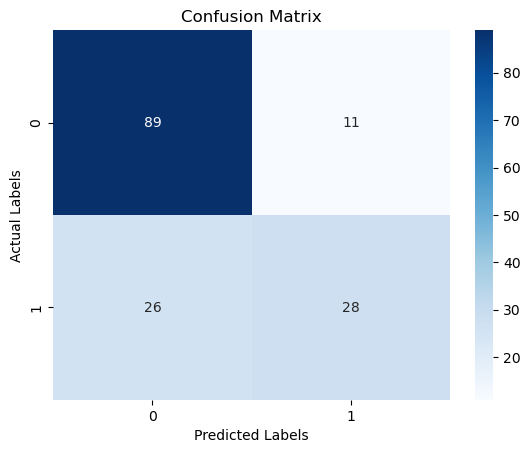

In [135]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()